In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

In [ ]:
with open ('../../data/raw_concat/diabetes.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data)
print(df.head())

  ParentLocationCode SpatialDim      Dim1             Value  NumericValue  \
0                AFR        MLI  SEX_FMLE  25.8 [15.1-37.8]          25.8   
1                AMR        HND  SEX_BTSX  20.4 [12.8-30.5]          20.4   
2                EMR        PSE  SEX_FMLE  19.8 [14.8-25.1]          19.8   
3                AMR        ECU   SEX_MLE  13.0 [10.4-15.6]          13.0   
4                EUR        NLD   SEX_MLE  13.3 [11.6-15.2]          13.3   

                           Date IndicatorCode  
0  2024-12-18T14:54:42.07+01:00   NCDMORT3070  
1  2024-12-18T14:54:42.07+01:00   NCDMORT3070  
2  2024-12-18T14:54:42.07+01:00   NCDMORT3070  
3  2024-12-18T14:54:42.07+01:00   NCDMORT3070  
4  2024-12-18T14:54:42.07+01:00   NCDMORT3070  


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 211564 entries, 0 to 211563
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ParentLocationCode  201994 non-null  str    
 1   SpatialDim          211564 non-null  str    
 2   Dim1                207102 non-null  str    
 3   Value               211564 non-null  str    
 4   NumericValue        205482 non-null  float64
 5   Date                211564 non-null  str    
 6   IndicatorCode       211564 non-null  str    
dtypes: float64(1), str(6)
memory usage: 11.3 MB


,NumericValue
count,205482.000000
mean,16.649353
std,30.958923
min,0.000000
25%,5.778044
50%,9.694469
75%,20.118644
max,1957.000000


In [ ]:
df['NumericValue'].isnull().sum()

np.int64(6082)

In [5]:
# remove null value
print(len(df))
df=df.dropna(subset=['NumericValue'])
print(len(df))
print(df["NumericValue"].isnull().sum())

211564
205482
0


In [11]:
#remove indicators that not relevant
unrelated = set(['NCD_GLUC_01', 'NCD_GLUC_02', 'NCD_GLUC_03', 'NCD_GLUC_04', 'SA_0000001421','SA_0000001440'])
df = df[~df['IndicatorCode'].isin(unrelated)]

In [12]:
indicators = df['IndicatorCode'].unique().tolist()
print(indicators)

['NCDMORT3070', 'NCD_DIABETES_PREVALENCE_AGESTD', 'NCD_DIABETES_PREVALENCE_CRUDE', 'NCD_DIABETES_TREATMENT_AGESTD', 'NCD_DIABETES_TREATMENT_CRUDE']


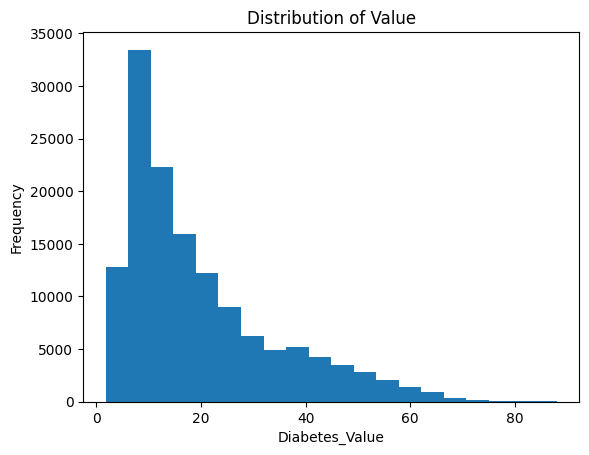

In [13]:
plt.figure()
plt.hist(df["NumericValue"], bins=20)
plt.xlabel("Diabetes_Value")
plt.ylabel("Frequency")
plt.title("Distribution of Value")
plt.show()


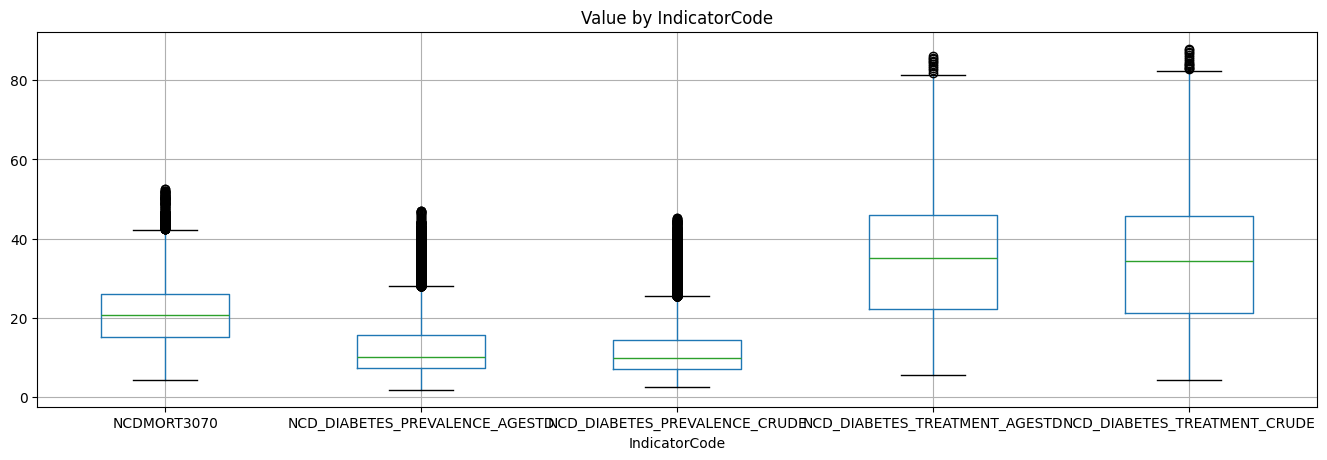

In [14]:
fig, ax = plt.subplots(figsize=(16,5))
df.boxplot(column="NumericValue", by="IndicatorCode", ax=ax)

ax.set_title("Value by IndicatorCode")
plt.suptitle("")
plt.show()